# `design.beams` — Full tour

Every constructor argument, every plot, every design mode, ACI checks, unit hot-swap, manual override, and the optimize sweep.

Beams have no P-M interaction diagram — they are flexural-shear elements per ACI 318-25 §9 and §18.6.

In [25]:
import matplotlib.pyplot as plt
from design import Concrete, Steel
from design.common.bar_schedule import BarSchedule
from design.beams import (
    Beam, BeamDemands,
    mpr, ve_capacity_design, v_seismic_from_mpr,
    rho_balanced, rho_max_beam, rho_min_beam,
    run_optimize, format_optimize_table,
)

## 1. One-shot construction

`Beam.rectangular(...)` builds RebarLayout + RectangularSection + Beam in a single call. `cover` is the clear cover to the outside edge of the stirrup — applied symmetrically top and bottom. Bar centroids are placed precisely at `cover + db_stirrup + db/2` (top and bot can have different diameters).

In [26]:
concrete = Concrete(fc=28)
steel    = Steel(fy=420, grade=60)

beam = Beam.rectangular(
    bw=400, h=700, cover=40,
    concrete=concrete, steel=steel,
    n_top=4, db_top=22,
    n_bot=4, db_bot=22,
    db_stirrup=10, n_legs=2, s_stirrup=100,
    ln=5000.0,
    seismic=True,
    Vg=80.0,                          # gravity shear at supports (kN)
    units=6,                          # kN_m_C
    bar_schedule=BarSchedule(
        longitudinal=[16, 20, 22, 25, 28],
        hoops=[10, 12],
    ),
    label='B-1A',
)
beam.summary()

=== B-1A ===  (units: kN_m_C)
Section   : 0.400x0.700 m
Materials : fc = 28 MPa, fy = 420 MPa
Rebar     : 8 bars, As_tot = 3041 mm^2
            rho  = 0.0059  (bottom)
            rho' = 0.0059  (top)
            range [rho_min = 0.0033 .. rho_max = 0.0142]
            rho_b = 0.0283  (rho_max = 0.5*rho_b)
phi*Mn+   : 332.2 kN.m
phi*Mn-   : 332.2 kN.m
phi*Vn    : 488.6 kN
Mpr+      : 476.6 kN.m
Mpr-      : 476.6 kN.m
TC        : True


## 2. Reinforcement ratios — sanity check

`rho_max = 0.5 · rho_balanced` is more restrictive than ACI §18.6.3.1 (0.025).

In [27]:
print(f'rho_min   = {rho_min_beam(28, 420):.4f}')
print(f'rho_b     = {rho_balanced(28, 420):.4f}')
print(f'rho_max   = {rho_max_beam(28, 420):.4f}   (= 0.5 · rho_b)')

rho_min   = 0.0033
rho_b     = 0.0283
rho_max   = 0.0142   (= 0.5 · rho_b)


## 3. Section plot

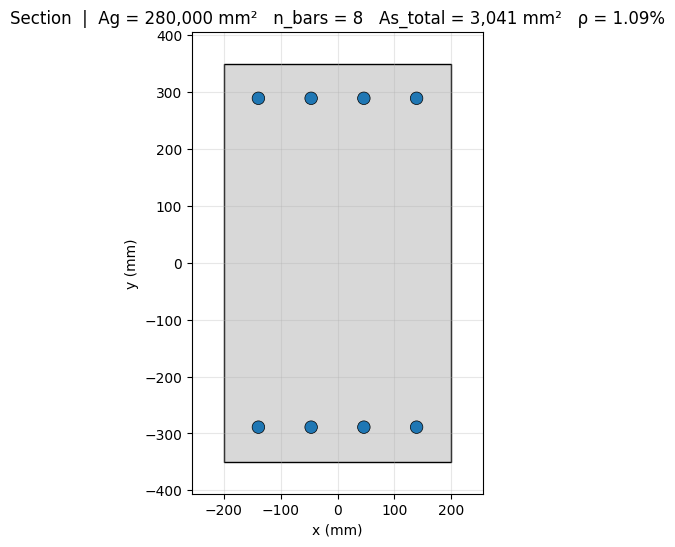

In [28]:
fig, ax = plt.subplots(figsize=(5, 6))
beam.plot.section(ax=ax)
plt.show()

## 4. Demands

Three stations × (Mu+, Mu-, Vu). Optional gravity shear per station (`Vg_i`, `Vg_mid`, `Vg_j`) — if omitted, `beam.Vg` is used at the supports and 0 at midspan (uniformly loaded assumption).

In [29]:
demands = BeamDemands(
    Mu_pos_i=250,    Mu_neg_i=200,   Vu_i=450,
    Mu_pos_mid=200, Mu_neg_mid=50,  Vu_mid=250,
    Mu_pos_j=100,    Mu_neg_j=100,   Vu_j=300,
    # Optional asymmetric gravity (uncomment to override beam.Vg):
    # Vg_i=120, Vg_mid=20, Vg_j=60,
)
demands

BeamDemands(Mu_pos_i=250, Mu_neg_i=200, Vu_i=450, Mu_pos_mid=200, Mu_neg_mid=50, Vu_mid=250, Mu_pos_j=100, Mu_neg_j=100, Vu_j=300, Vg_i=None, Vg_mid=None, Vg_j=None)

## 5. ACI 318-25 checks

In [30]:
beam.print_checks(demands)

=== B-1A -- ACI 318-25 Checks ===  (units: kN_m_C)
§9.6.1.2 / 22.2  Cuantia (range 0.5*rho_b):
  rho  (bot) = 0.0059    [0.0033 .. 0.0142]   OK
  rho' (top) = 0.0059    [0.0033 .. 0.0142]   OK
  rho_balanced = 0.0283    (ACI §18.6.3.1 SMF cap = 0.0250)
§21.2.2          Tension-controlled                          : OK
§18.6.3.2        >=2 bars continuous (top, bot)            : requires layout check at apply()
§18.6.3.3        phi_Mn+ >= 0.5 phi_Mn-                    : 1.00   OK
§18.6.3.4        phi_Mn anywhere >= 0.25 max               : 1.00   OK
Demand ratios (per station):
  M (i)  +/-: 0.75 / 0.60
  M (mid)+/-: 0.60 / 0.15
  M (j)  +/-: 0.30 / 0.30
  V (i/mid/j): 0.92 / 0.51 / 0.61
  Overall passed = True


## 6. Demand visualization

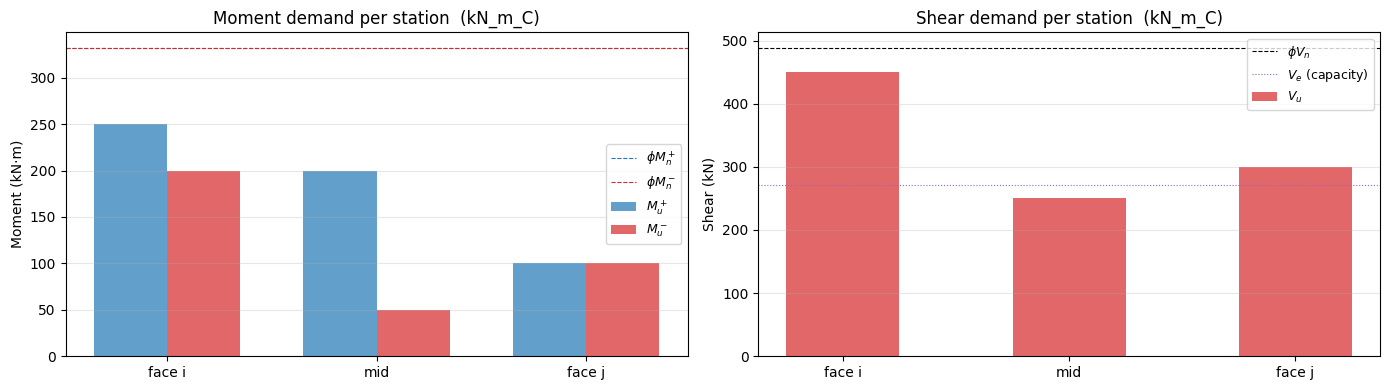

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
beam.plot.moment_envelope(demands, ax=axes[0])
beam.plot.shear_envelope(demands, ax=axes[1])
plt.tight_layout()
plt.show()

## 7. Three design modes

- `minimum`  : §9.6.1.2 + §9.6.3.4 + §18.6.4 only.
- `demand`   : As for Mu_*_X per station, av/s for max(|Vu|).
- `capacity` : Mpr-based Ve at each station: `Ve_X = V_seismic + Vg_X`. Vc=0 in lo if §18.6.5.2 (a)+(b) hold.
- `envelope` : pointwise worst.

In [32]:
results = beam.design(demands)
beam.print_design(results, demands=demands)

=== B-1A Design Results ===  (units: kN_m_C)

--- PROVIDED ---
  Top         : 4φ22    (As = 1521 mm^2)
  Bottom      : 4φ22    (As = 1521 mm^2)
  Stirrups    : φ10 x 2 legs @ 0.100 m
  phi*Mn (+/-): 332.2 kN.m / 332.2 kN.m
  phi*Vn      : 488.6 kN
  Mpr (+/-)   : 476.6 kN.m / 476.6 kN.m   -> Ve_capacity = 270.7 kN
  rho / rho'  : 0.0059 / 0.0059    range [0.0033 .. 0.0142]    OK
  Demand check: ratio M = 0.75   ratio V (i/m/j) = 0.92 / 0.51 / 0.61   passed = True

--- MINIMUM ---
  Top         : 5φ16    (As = 1005 mm^2)
  Bottom      : 5φ16    (As = 1005 mm^2)
  Stirrups    : φ10 x 2 legs @ 0.096 m   (middle s = 0.320 m, lo = 1.400 m)
  Mpr (+/-)   : 476.6 kN.m / 476.6 kN.m   -> Ve_capacity = 270.7 kN
  phi*Vn      : 501.8 kN   Ve/phiVn = 0.54

--- DEMAND ---
  Top         : 5φ16    (As = 1005 mm^2)
  Bottom      : 6φ16    (As = 1206 mm^2)
  Stirrups    : φ10 x 2 legs @ 0.096 m   (middle s = 0.320 m, lo = 1.400 m)
  Mpr (+/-)   : 476.6 kN.m / 476.6 kN.m   -> Ve_capacity = 270.7 kN
  V

## 8. Per-station Vg in the capacity check

ACI §18.6.5.1 + Fig. R18.6.5 say the beam is loaded with gravity AND vertical seismic along its span. The seismic-induced shear from the Mpr couple is constant; the gravity shear varies. We compute Ve at each station independently. The maximum governs the stirrup design in `lo`.

In [33]:
cap = beam.capacity()
V_seismic = v_seismic_from_mpr(
    Mpr_pos_i=cap.Mn_pr_pos, Mpr_neg_i=cap.Mn_pr_neg,
    Mpr_pos_j=cap.Mn_pr_pos, Mpr_neg_j=cap.Mn_pr_neg,
    ln=beam.ln,
)
print(f'V_seismic (constant) = {V_seismic:.1f} kN')
print()
print('Case A — uniform load (beam.Vg = 80 kN at supports, 0 at mid):')
print(f'  Ve_i   = {V_seismic + 80:.1f} kN')
print(f'  Ve_mid = {V_seismic + 0 :.1f} kN')
print(f'  Ve_j   = {V_seismic + 80:.1f} kN')
print()
print('Case B — asymmetric (Vg_i=120, Vg_mid=20, Vg_j=60):')
dem_asym = BeamDemands(
    Mu_pos_i=80, Mu_neg_i=320, Vu_i=210,
    Mu_pos_mid=350, Mu_neg_mid=50, Vu_mid=80,
    Mu_pos_j=80, Mu_neg_j=320, Vu_j=205,
    Vg_i=120, Vg_mid=20, Vg_j=60,
)
p = beam.design(dem_asym).capacity
print(f'  Ve_i   = {p.Vu_i_used:.1f} kN  (governs lo)')
print(f'  Ve_mid = {p.Vu_mid_used:.1f} kN')
print(f'  Ve_j   = {p.Vu_j_used:.1f} kN')
print(f'  Ve_capacity = {p.Ve_capacity:.1f} kN  = max(Ve_i, Ve_j)')

V_seismic (constant) = 190.7 kN

Case A — uniform load (beam.Vg = 80 kN at supports, 0 at mid):
  Ve_i   = 270.7 kN
  Ve_mid = 190.7 kN
  Ve_j   = 270.7 kN

Case B — asymmetric (Vg_i=120, Vg_mid=20, Vg_j=60):
  Ve_i   = 310.7 kN  (governs lo)
  Ve_mid = 210.7 kN
  Ve_j   = 250.7 kN
  Ve_capacity = 310.7 kN  = max(Ve_i, Ve_j)


## 9. Force longitudinal and transverse diameters

Pass `db_top`, `db_bot`, `db_stirrup` to fix diameters; the picker computes how many bars / how many legs / what spacing satisfy the demand at those diameters.

**Adaptive spacing**: if you also fix `n_legs`, the spacing is computed as `min(s_§18.6.4.4, av_provided/av_s_required)`. Useful when you want, say, a single closed stirrup (n_legs=2) with whatever tight spacing the demand requires.

In [34]:
# Case A — fix only the diameters; picker decides n_top, n_bot, n_legs and uses §18.6.4.4 spacing
ra = beam.design(demands, db_top=20, db_bot=20, db_stirrup=10).envelope
print(f'A) Top {ra.n_top}φ{ra.db_top:.0f}, Bot {ra.n_bot}φ{ra.db_bot:.0f}, '
      f'stirrup φ{ra.db_stirrup:.0f} × {ra.n_legs} legs @ {ra.spacing_confined:.0f} mm')

# Case B — fix db AND n_legs; picker adapts spacing to match the demand
rb = beam.design(demands, db_top=20, db_bot=20, db_stirrup=10, n_legs=2).envelope
print(f'B) Top {rb.n_top}φ{rb.db_top:.0f}, Bot {rb.n_bot}φ{rb.db_bot:.0f}, '
      f'stirrup φ{rb.db_stirrup:.0f} × {rb.n_legs} legs @ {rb.spacing_confined:.0f} mm')
if rb.notes:
    for n in rb.notes:
        print(f'   note: {n}')

A) Top 3φ20, Bot 4φ20, stirrup φ10 × 2 legs @ 96 mm
B) Top 3φ20, Bot 4φ20, stirrup φ10 × 2 legs @ 96 mm
   note: [capacity] §18.6.5.2 — Vc = 0 in lo (seismic share = 70% of Ve, Pu ≈ 0).


## 10. Unit hot-swap

In [35]:
for code in [5, 6, 11, 12, 14, 16]:
    beam.set_units(code)
    cap = beam.capacity()
    u = beam.units
    print(f'{u.name:12s}   phi_Vn = {cap.phi_Vn*u.force_factor:10.2f} {u.force}'
          f'   phi_Mn+ = {cap.phi_Mn_pos*u.moment_factor:10.2f} {u.force}.{u.length}')
beam.set_units(6)

kN_mm_C        phi_Vn =     488.62 kN   phi_Mn+ =  332211.66 kN.mm
kN_m_C         phi_Vn =     488.62 kN   phi_Mn+ =     332.21 kN.m
Tonf_mm_C      phi_Vn =      49.83 Tonf   phi_Mn+ =   33876.15 Tonf.mm
Tonf_m_C       phi_Vn =      49.83 Tonf   phi_Mn+ =      33.88 Tonf.m
kgf_cm_C       phi_Vn =   49825.62 kgf   phi_Mn+ = 3387615.46 kgf.cm
Tonf_cm_C      phi_Vn =      49.83 Tonf   phi_Mn+ =    3387.62 Tonf.cm


Beam(label='B-1A', section=400×700 mm, fc=28 MPa, units=kN_m_C)

## 11. Apply any mode and verify

`beam.apply(<proposal>)` adopts the detailing. Then `beam.print_checks(demands)` verifies the full ACI suite (ρ range, tension-controlled, §18.6.3.2/3/4, demand ratios per station). Use `beam.current_proposal(demands)` to snapshot the PROVIDED state before exploring, so you can revert.

In [42]:
# Snapshot the PROVIDED before we explore
snapshot = beam.current_proposal(demands)

# Try the envelope
beam = beam.apply(results.envelope)
print('After apply(envelope):')
chk_env = beam.check(demands)
print(f'  ratio M = {chk_env.ratio_M_overall:.2f}  '
      f'ratio V max = {chk_env.ratio_V_overall:.2f}  passed = {chk_env.passed}')

# Try the minimum (just to see)
beam = beam.apply(results.minimum)
chk_min = beam.check(demands)
print(f'After apply(minimum):  ratio M = {chk_min.ratio_M_overall:.2f}  '
      f'ratio V max = {chk_min.ratio_V_overall:.2f}  passed = {chk_min.passed}')

# Revert to the original PROVIDED
beam = beam.apply(snapshot)
chk_prov = beam.check(demands)
print(f'After apply(snapshot):  ratio M = {chk_prov.ratio_M_overall:.2f}  '
      f'ratio V max = {chk_prov.ratio_V_overall:.2f}  passed = {chk_prov.passed}')

After apply(envelope):
  ratio M = 0.97  ratio V max = 0.89  passed = True
After apply(minimum):  ratio M = 1.13  ratio V max = 0.89  passed = False
After apply(snapshot):  ratio M = 0.75  ratio V max = 0.92  passed = True


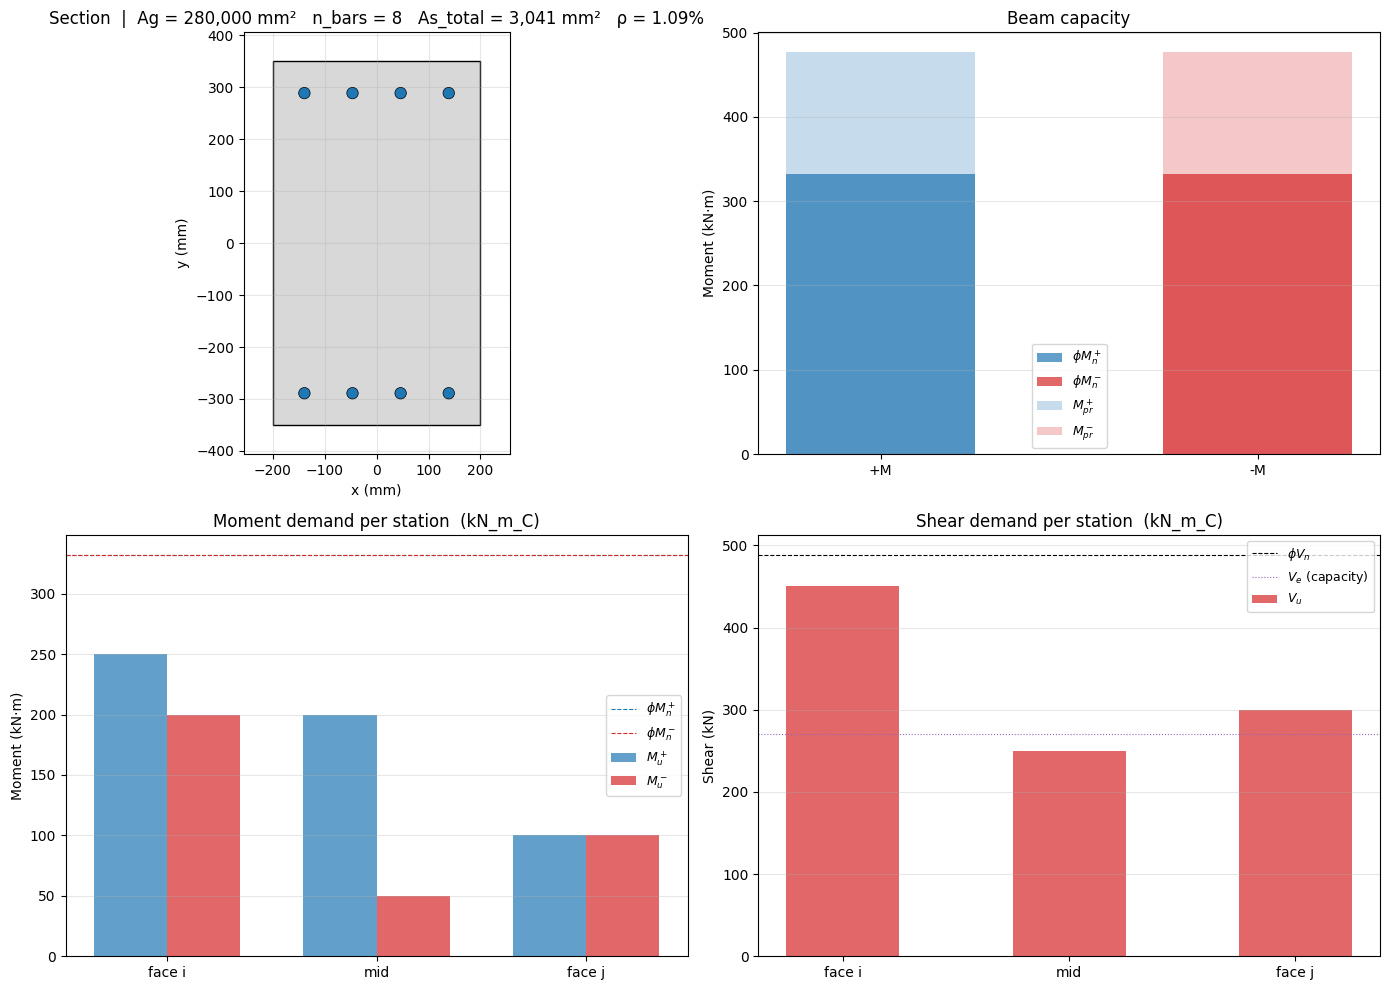

In [37]:
fig = beam.plot.dashboard(demands=demands)
plt.show()

## 12. Optimize sweep

In [38]:
alts = run_optimize(beam, demands, sort_by='rho_total')
print(format_optimize_table(alts, top_n=10))

rank        top        bot         stirrup     rho_t     rho_l   rho_tot                   tag
                                             (kg/m3)   (kg/m3)   (kg/m3)                      
----------------------------------------------------------------------------------------------
   1       3φ20       3φ22         φ10 x 2      43.1      58.4     101.5                      
   2       2φ25       3φ22         φ10 x 2      43.1      59.5     102.6                      
   3       5φ16       3φ22         φ10 x 2      43.1      60.2     103.3                      
   4       3φ20       6φ16         φ10 x 2      43.1      60.2     103.4                      
   5       3φ20       2φ28         φ10 x 2      43.1      60.9     104.1                      
   6       2φ25       6φ16         φ10 x 2      43.1      61.3     104.5                      
   7       3φ20       4φ20         φ10 x 2      43.1      61.7     104.8                      
   8       5φ16       6φ16         φ10 x 2      43